# Event Tree Analysis of Railway Signal Failure at a Junction



The initiating event is:

**Railway junction signal displays an incorrect aspect**

After this event, the system response depends on whether each protection barrier succeeds or fails.

The barriers considered are:

1. Fault detection system  
2. Control room alarm  
3. Operator response  
4. Emergency braking system  



#Import Libraries and Define Data Classes

This block imports the required libraries and defines the main data structures.

`ETABarrier` represents one barrier in the event tree.

`ETAPathResult` stores the result of one complete event-tree path.

In [1]:
# Allows forward references in type hints
from __future__ import annotations

# Used to create simple data-holding classes
from dataclasses import dataclass

# Type hints for readability
from typing import Dict, List, Optional, Tuple, Callable

# Used for file and folder handling
import os

# Used to create temporary folders for icon files
import tempfile

# Used for grouping probabilities
from collections import defaultdict

# Used to create tables
import pandas as pd

# Used to draw custom icons
import matplotlib.pyplot as plt

# Shapes used for icons
from matplotlib.patches import Circle, Rectangle, FancyBboxPatch

# Used to generate event tree diagram
from graphviz import Digraph

# Used to display images and tables in Colab
from IPython.display import Image, display


@dataclass
class ETABarrier:
    # Barrier name
    name: str

    # Probability that the barrier succeeds
    success_probability: float

    # Barrier type: SECURITY, SAFETY, or HUMAN
    barrier_type: str = "SAFETY"

    def validate(self) -> None:
        # Check probability range
        if not (0.0 <= self.success_probability <= 1.0):
            raise ValueError(f"Barrier '{self.name}' must have success probability between 0 and 1.")

        # Valid barrier types
        valid_types = {"SECURITY", "SAFETY", "HUMAN"}

        # Check barrier type
        if self.barrier_type not in valid_types:
            raise ValueError(f"Barrier '{self.name}' has invalid type '{self.barrier_type}'.")


@dataclass
class ETAPathResult:
    # Unique path number
    path_id: int

    # Success/failure decisions for barriers
    decisions: List[bool]

    # Probability of the full path
    path_probability: float

    # Final outcome text
    outcome_name: str

    # Final outcome category
    outcome_category: str

# Helper Functions and ETA Icons

This block defines helper functions and creates simple icons for the event tree.

The helper functions calculate failure probability, format probability values, wrap long text, and classify outcomes.

In [2]:
def failure_probability(success_probability: float) -> float:
    # Failure probability is 1 minus success probability
    return 1.0 - success_probability


def format_prob(p: float, decimals: int = 4) -> str:
    # Format probability neatly
    return f"P = {round(p, decimals):g}"


def branch_text(decision: bool) -> str:
    # Convert True/False into Success/Failure
    return "Success" if decision else "Failure"


def wrap_text(text: str, max_len: int = 26, max_lines: int = 5) -> str:
    # Split text into words
    words = text.split()

    # Store wrapped lines
    lines = []

    # Store current line
    current = ""

    # Build wrapped text
    for word in words:
        candidate = f"{current} {word}".strip()

        if len(candidate) <= max_len:
            current = candidate
        else:
            if current:
                lines.append(current)
            current = word

    # Add final line
    if current:
        lines.append(current)

    # Limit number of lines
    if len(lines) > max_lines:
        lines = lines[:max_lines]
        lines[-1] = lines[-1][:max(0, max_len - 3)] + "..."

    # Return wrapped text
    return "\n".join(lines)


def classify_outcome(outcome_name: str) -> str:
    # Convert outcome text to lowercase
    lower_name = outcome_name.lower()

    # Safe keywords
    if any(k in lower_name for k in ["safe", "stable", "maintained", "controlled", "prevented"]):
        return "SAFE"

    # Partial failure keywords
    if any(k in lower_name for k in ["delayed", "degraded", "partial", "recovery", "limited"]):
        return "PARTIAL FAILURE"

    # Default category
    return "CATASTROPHIC FAILURE"


def outcome_fillcolor(category: str) -> str:
    # Green for safe
    if category == "SAFE":
        return "#D9EAD3"

    # Yellow for partial failure
    if category == "PARTIAL FAILURE":
        return "#FFF2CC"

    # Red for catastrophic failure
    return "#F4CCCC"


def outcome_icon_key(category: str) -> str:
    # Safe icon
    if category == "SAFE":
        return "SAFE"

    # Partial icon
    if category == "PARTIAL FAILURE":
        return "PARTIAL"

    # Hazard icon
    return "HAZARD"


def create_eta_icons(output_dir: str) -> Dict[str, str]:
    # Create icon folder
    os.makedirs(output_dir, exist_ok=True)

    # Store icon paths
    paths = {
        "INIT": os.path.join(output_dir, "init_event.png"),
        "SECURITY": os.path.join(output_dir, "security_barrier.png"),
        "SAFETY": os.path.join(output_dir, "safety_barrier.png"),
        "HUMAN": os.path.join(output_dir, "human_barrier.png"),
        "SAFE": os.path.join(output_dir, "safe_outcome.png"),
        "PARTIAL": os.path.join(output_dir, "partial_outcome.png"),
        "HAZARD": os.path.join(output_dir, "hazard_outcome.png"),
    }

    # Create initiating event icon
    fig, ax = plt.subplots(figsize=(2.3, 1.0))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.add_patch(FancyBboxPatch((0.08, 0.20), 0.84, 0.60,
                                boxstyle="round,pad=0.03,rounding_size=0.05",
                                facecolor="#F4CCCC", edgecolor="black", linewidth=1.2))
    ax.text(0.5, 0.5, "INIT", ha="center", va="center", fontsize=11, weight="bold")
    plt.savefig(paths["INIT"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # Create SECURITY, SAFETY, and HUMAN icons
    icon_specs = [
        ("SECURITY", "#F4CCCC", "SEC", 8.5),
        ("SAFETY", "#D9EAD3", "SAFE", 7.5),
        ("HUMAN", "#CFE2F3", "H", 11),
    ]

    for key, color, label, size in icon_specs:
        fig, ax = plt.subplots(figsize=(1.4, 1.4))
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis("off")
        ax.add_patch(Circle((0.5, 0.5), 0.34, facecolor=color, edgecolor="black", linewidth=1.2))
        ax.text(0.5, 0.5, label, ha="center", va="center", fontsize=size, weight="bold")
        plt.savefig(paths[key], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
        plt.close(fig)

    # Create outcome icons
    outcome_specs = [
        ("SAFE", "#D9EAD3", "SAFE"),
        ("PARTIAL", "#FFF2CC", "PARTIAL"),
        ("HAZARD", "#EA9999", "HAZARD"),
    ]

    for key, color, label in outcome_specs:
        fig, ax = plt.subplots(figsize=(2.1, 1.0))
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis("off")
        ax.add_patch(Rectangle((0.08, 0.18), 0.84, 0.64,
                               facecolor=color, edgecolor="black", linewidth=1.2))
        ax.text(0.5, 0.5, label, ha="center", va="center", fontsize=10, weight="bold")
        plt.savefig(paths[key], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
        plt.close(fig)

    # Return icon file paths
    return paths

# Event Tree Class

This block defines the main `EventTree` class.

It validates the model, generates all possible paths, calculates path probabilities, and creates result tables.

In [3]:
class EventTree:
    def __init__(
        self,
        initiating_event: str,
        barriers: List[ETABarrier],
        title: str = "Event Tree Analysis",
        outcome_logic: Optional[Callable[[List[bool]], str]] = None
    ) -> None:
        # Store initiating event
        self.initiating_event = initiating_event

        # Store barrier list
        self.barriers = barriers

        # Store title
        self.title = title

        # Store custom outcome function
        self.outcome_logic = outcome_logic

        # Validate input
        self._validate_tree()

    def _validate_tree(self) -> None:
        # Check initiating event
        if not self.initiating_event.strip():
            raise ValueError("Initiating event must not be empty.")

        # Check barrier list
        if not self.barriers:
            raise ValueError("At least one barrier is required.")

        # Validate each barrier
        for barrier in self.barriers:
            barrier.validate()

    def _determine_outcome(self, decisions: List[bool]) -> Tuple[str, str]:
        # Use custom outcome logic if provided
        if self.outcome_logic is not None:
            outcome_name = self.outcome_logic(decisions)
            outcome_category = classify_outcome(outcome_name)
            return outcome_name, outcome_category

        # Default safe case
        if all(decisions):
            return "All barriers succeed - Safe state maintained", "SAFE"

        # Default partial failure case
        if decisions[-1]:
            return "Late recovery after earlier failures", "PARTIAL FAILURE"

        # Default catastrophic case
        return "Barrier failure sequence leads to catastrophic state", "CATASTROPHIC FAILURE"

    def generate_paths(self) -> List[ETAPathResult]:
        # Store path results
        results: List[ETAPathResult] = []

        # Start path numbering
        path_counter = 1

        def recurse(index: int, current_decisions: List[bool], current_probability: float) -> None:
            # Allow path counter update
            nonlocal path_counter

            # If all barriers processed, save path
            if index == len(self.barriers):
                outcome_name, outcome_category = self._determine_outcome(current_decisions)

                results.append(
                    ETAPathResult(
                        path_id=path_counter,
                        decisions=current_decisions.copy(),
                        path_probability=current_probability,
                        outcome_name=outcome_name,
                        outcome_category=outcome_category
                    )
                )

                path_counter += 1
                return

            # Current barrier
            barrier = self.barriers[index]

            # Success branch
            current_decisions.append(True)
            recurse(index + 1, current_decisions, current_probability * barrier.success_probability)
            current_decisions.pop()

            # Failure branch
            current_decisions.append(False)
            recurse(index + 1, current_decisions, current_probability * failure_probability(barrier.success_probability))
            current_decisions.pop()

        # Start recursion
        recurse(0, [], 1.0)

        # Return all paths
        return results

    def barrier_table(self) -> pd.DataFrame:
        # Store rows
        rows = []

        # Add each barrier
        for i, barrier in enumerate(self.barriers, start=1):
            rows.append({
                "ID": i,
                "Barrier": barrier.name,
                "Barrier Type": barrier.barrier_type,
                "Success Probability": format_prob(barrier.success_probability),
                "Failure Probability": format_prob(failure_probability(barrier.success_probability))
            })

        return pd.DataFrame(rows)

    def path_table(self) -> pd.DataFrame:
        # Store rows
        rows = []

        # Add each path
        for result in self.generate_paths():
            decision_text = " | ".join(
                f"{self.barriers[i].name}: {branch_text(result.decisions[i])}"
                for i in range(len(self.barriers))
            )

            rows.append({
                "Path ID": result.path_id,
                "Branch Decisions": decision_text,
                "Path Probability": format_prob(result.path_probability),
                "Outcome": result.outcome_name,
                "Outcome Category": result.outcome_category
            })

        return pd.DataFrame(rows)

    def outcome_summary_table(self) -> pd.DataFrame:
        # Group probability by outcome
        grouped = defaultdict(float)

        # Sum probabilities
        for result in self.generate_paths():
            grouped[(result.outcome_name, result.outcome_category)] += result.path_probability

        # Store rows
        rows = []

        # Sort by probability
        for i, ((outcome_name, category), total_prob) in enumerate(
            sorted(grouped.items(), key=lambda x: x[1], reverse=True),
            start=1
        ):
            rows.append({
                "ID": i,
                "Outcome": outcome_name,
                "Outcome Category": category,
                "Total Probability": format_prob(total_prob)
            })

        return pd.DataFrame(rows)

    def category_comparison_table(self) -> pd.DataFrame:
        # Store totals by category
        totals = defaultdict(float)

        # Sum category probabilities
        for result in self.generate_paths():
            totals[result.outcome_category] += result.path_probability

        # Fixed category order
        categories = ["SAFE", "PARTIAL FAILURE", "CATASTROPHIC FAILURE"]

        # Store rows
        rows = []

        # Add each category
        for i, category in enumerate(categories, start=1):
            rows.append({
                "ID": i,
                "Category": category,
                "Total Probability": format_prob(totals.get(category, 0.0))
            })

        return pd.DataFrame(rows)

#  Visualization and Dashboard

This block adds visualization and dashboard methods to the `EventTree` class.

The diagram is drawn using Graphviz.

The dashboard prints summary probabilities and returns all result tables.

In [4]:
class EventTree(EventTree):
    def visualize_event_tree(self, save_path: Optional[str] = None) -> str:
        # Choose output name
        output_name = save_path if save_path else "eta_event_tree"

        # Create temporary icon folder
        temp_dir = tempfile.mkdtemp(prefix="eta_icons_")

        # Create icons
        icon_paths = create_eta_icons(temp_dir)

        # Create Graphviz object
        dot = Digraph("ETA", format="png")

        # Set diagram layout
        dot.attr(rankdir="LR", splines="polyline", nodesep="0.85", ranksep="1.1")

        # Set fonts
        dot.attr(fontname="Helvetica")
        dot.attr("node", fontname="Helvetica")
        dot.attr("edge", fontname="Helvetica", fontsize="9")

        # Initiating event IDs
        init_event_id = "init_event"
        init_symbol_id = "init_symbol"

        # Add initiating event box
        dot.node(
            init_event_id,
            label=wrap_text(self.initiating_event, max_len=28, max_lines=4),
            shape="box",
            style="rounded,filled",
            fillcolor="white",
            color="black",
            width="2.9",
            height="0.95",
            penwidth="1.2"
        )

        # Add initiating event icon
        dot.node(
            init_symbol_id,
            label="",
            shape="none",
            image=icon_paths["INIT"],
            imagescale="true",
            width="1.1",
            height="0.6",
            fixedsize="true"
        )

        # Connect event to icon
        dot.edge(init_event_id, init_symbol_id, arrowhead="none", penwidth="1.1")

        # Start from initiating icon
        current_nodes = [init_symbol_id]

        # Add barriers level by level
        for level, barrier in enumerate(self.barriers, start=1):
            next_nodes = []

            for parent_idx, parent_node in enumerate(current_nodes):
                barrier_event_id = f"b{level}_{parent_idx}_event"
                barrier_symbol_id = f"b{level}_{parent_idx}_symbol"

                # Add barrier text box
                dot.node(
                    barrier_event_id,
                    label=wrap_text(barrier.name, max_len=26, max_lines=4),
                    shape="box",
                    style="rounded,filled",
                    fillcolor="white",
                    color="black",
                    width="2.6",
                    height="0.85",
                    penwidth="1.1"
                )

                # Add barrier icon
                dot.node(
                    barrier_symbol_id,
                    label="",
                    shape="none",
                    image=icon_paths[barrier.barrier_type],
                    imagescale="true",
                    width="0.78",
                    height="0.56",
                    fixedsize="true"
                )

                # Connect parent to barrier
                dot.edge(parent_node, barrier_event_id, arrowhead="none", penwidth="1.0")

                # Connect barrier text to icon
                dot.edge(barrier_event_id, barrier_symbol_id, arrowhead="none", penwidth="1.0")

                # Success and failure stubs
                success_stub = f"b{level}_{parent_idx}_S"
                failure_stub = f"b{level}_{parent_idx}_F"

                # Add success label
                dot.node(success_stub, label="Success", shape="plaintext", fontcolor="darkgreen", fontsize="10")

                # Add failure label
                dot.node(failure_stub, label="Failure", shape="plaintext", fontcolor="red", fontsize="10")

                # Format branch probabilities
                s_prob = format_prob(barrier.success_probability)
                f_prob = format_prob(failure_probability(barrier.success_probability))

                # Add success edge
                dot.edge(barrier_symbol_id, success_stub, label=f"S\n{s_prob}", color="darkgreen", penwidth="1.1")

                # Add failure edge
                dot.edge(barrier_symbol_id, failure_stub, label=f"F\n{f_prob}", color="red", penwidth="1.1")

                # Store next nodes
                next_nodes.extend([success_stub, failure_stub])

            # Move to next barrier level
            current_nodes = next_nodes

        # Generate path results
        all_paths = self.generate_paths()

        # Add outcome nodes
        for idx, result in enumerate(all_paths):
            parent_stub = current_nodes[idx]
            outcome_id = f"outcome_{idx}"

            label_text = (
                f"Path {result.path_id}\n"
                f"{wrap_text(result.outcome_name, max_len=28, max_lines=5)}\n"
                f"{format_prob(result.path_probability)}"
            )

            # Add outcome box
            dot.node(
                outcome_id,
                label=label_text,
                shape="box",
                style="rounded,filled",
                fillcolor=outcome_fillcolor(result.outcome_category),
                color="black",
                image=icon_paths[outcome_icon_key(result.outcome_category)],
                labelloc="b",
                imagescale="true",
                width="2.9",
                height="1.2",
                fontsize="8.5",
                penwidth="1.2"
            )

            # Choose edge color
            edge_color = (
                "darkgreen" if result.outcome_category == "SAFE"
                else "goldenrod" if result.outcome_category == "PARTIAL FAILURE"
                else "red"
            )

            # Connect final branch to outcome
            dot.edge(parent_stub, outcome_id, arrowhead="none", color=edge_color, penwidth="1.2")

        # Render image
        png_path = dot.render(output_name, cleanup=True)

        # Display image
        if os.path.exists(png_path):
            display(Image(filename=png_path))
        else:
            print("Could not find generated ETA image. Please check Graphviz installation.")

        # Print saved path
        print(f"ETA diagram saved as: {png_path}")

        return png_path

    def run_dashboard(self, image_path: Optional[str] = None) -> Dict[str, pd.DataFrame]:
        # Generate paths
        path_results = self.generate_paths()

        # Calculate category totals
        safe_total = sum(p.path_probability for p in path_results if p.outcome_category == "SAFE")
        partial_total = sum(p.path_probability for p in path_results if p.outcome_category == "PARTIAL FAILURE")
        catastrophic_total = sum(p.path_probability for p in path_results if p.outcome_category == "CATASTROPHIC FAILURE")

        # Print summary
        print("=" * 110)
        print(self.title.upper())
        print("=" * 110)
        print()
        print(f"Initiating Event: {self.initiating_event}")
        print(f"Total Number of Paths: {len(path_results)}")
        print(f"Safe Outcome Probability: {format_prob(safe_total)}")
        print(f"Partial Failure Probability: {format_prob(partial_total)}")
        print(f"Catastrophic Failure Probability: {format_prob(catastrophic_total)}")
        print()

        # Display diagram
        self.visualize_event_tree(save_path=image_path)

        # Create result tables
        barrier_df = self.barrier_table()
        path_df = self.path_table()
        outcome_df = self.outcome_summary_table()
        category_df = self.category_comparison_table()

        # Return result tables
        return {
            "barrier_probability_table": barrier_df,
            "path_outcome_table": path_df,
            "final_outcome_summary": outcome_df,
            "category_comparison": category_df,
        }

#  Railway Signal Case Study and Run Analysis

This block defines the railway-specific outcome logic, builds the ETA case study, and runs the final analysis.

The initiating event is:

**Railway junction signal displays an incorrect aspect**

The barriers are:

1. Fault detection system
2. Control room alarm
3. Operator response
4. Emergency braking system

EVENT TREE ANALYSIS OF RAILWAY SIGNAL FAILURE AT A JUNCTION

Initiating Event: Railway junction signal displays an incorrect aspect
Total Number of Paths: 16
Safe Outcome Probability: P = 0.7635
Partial Failure Probability: P = 0.2363
Catastrophic Failure Probability: P = 0.0002



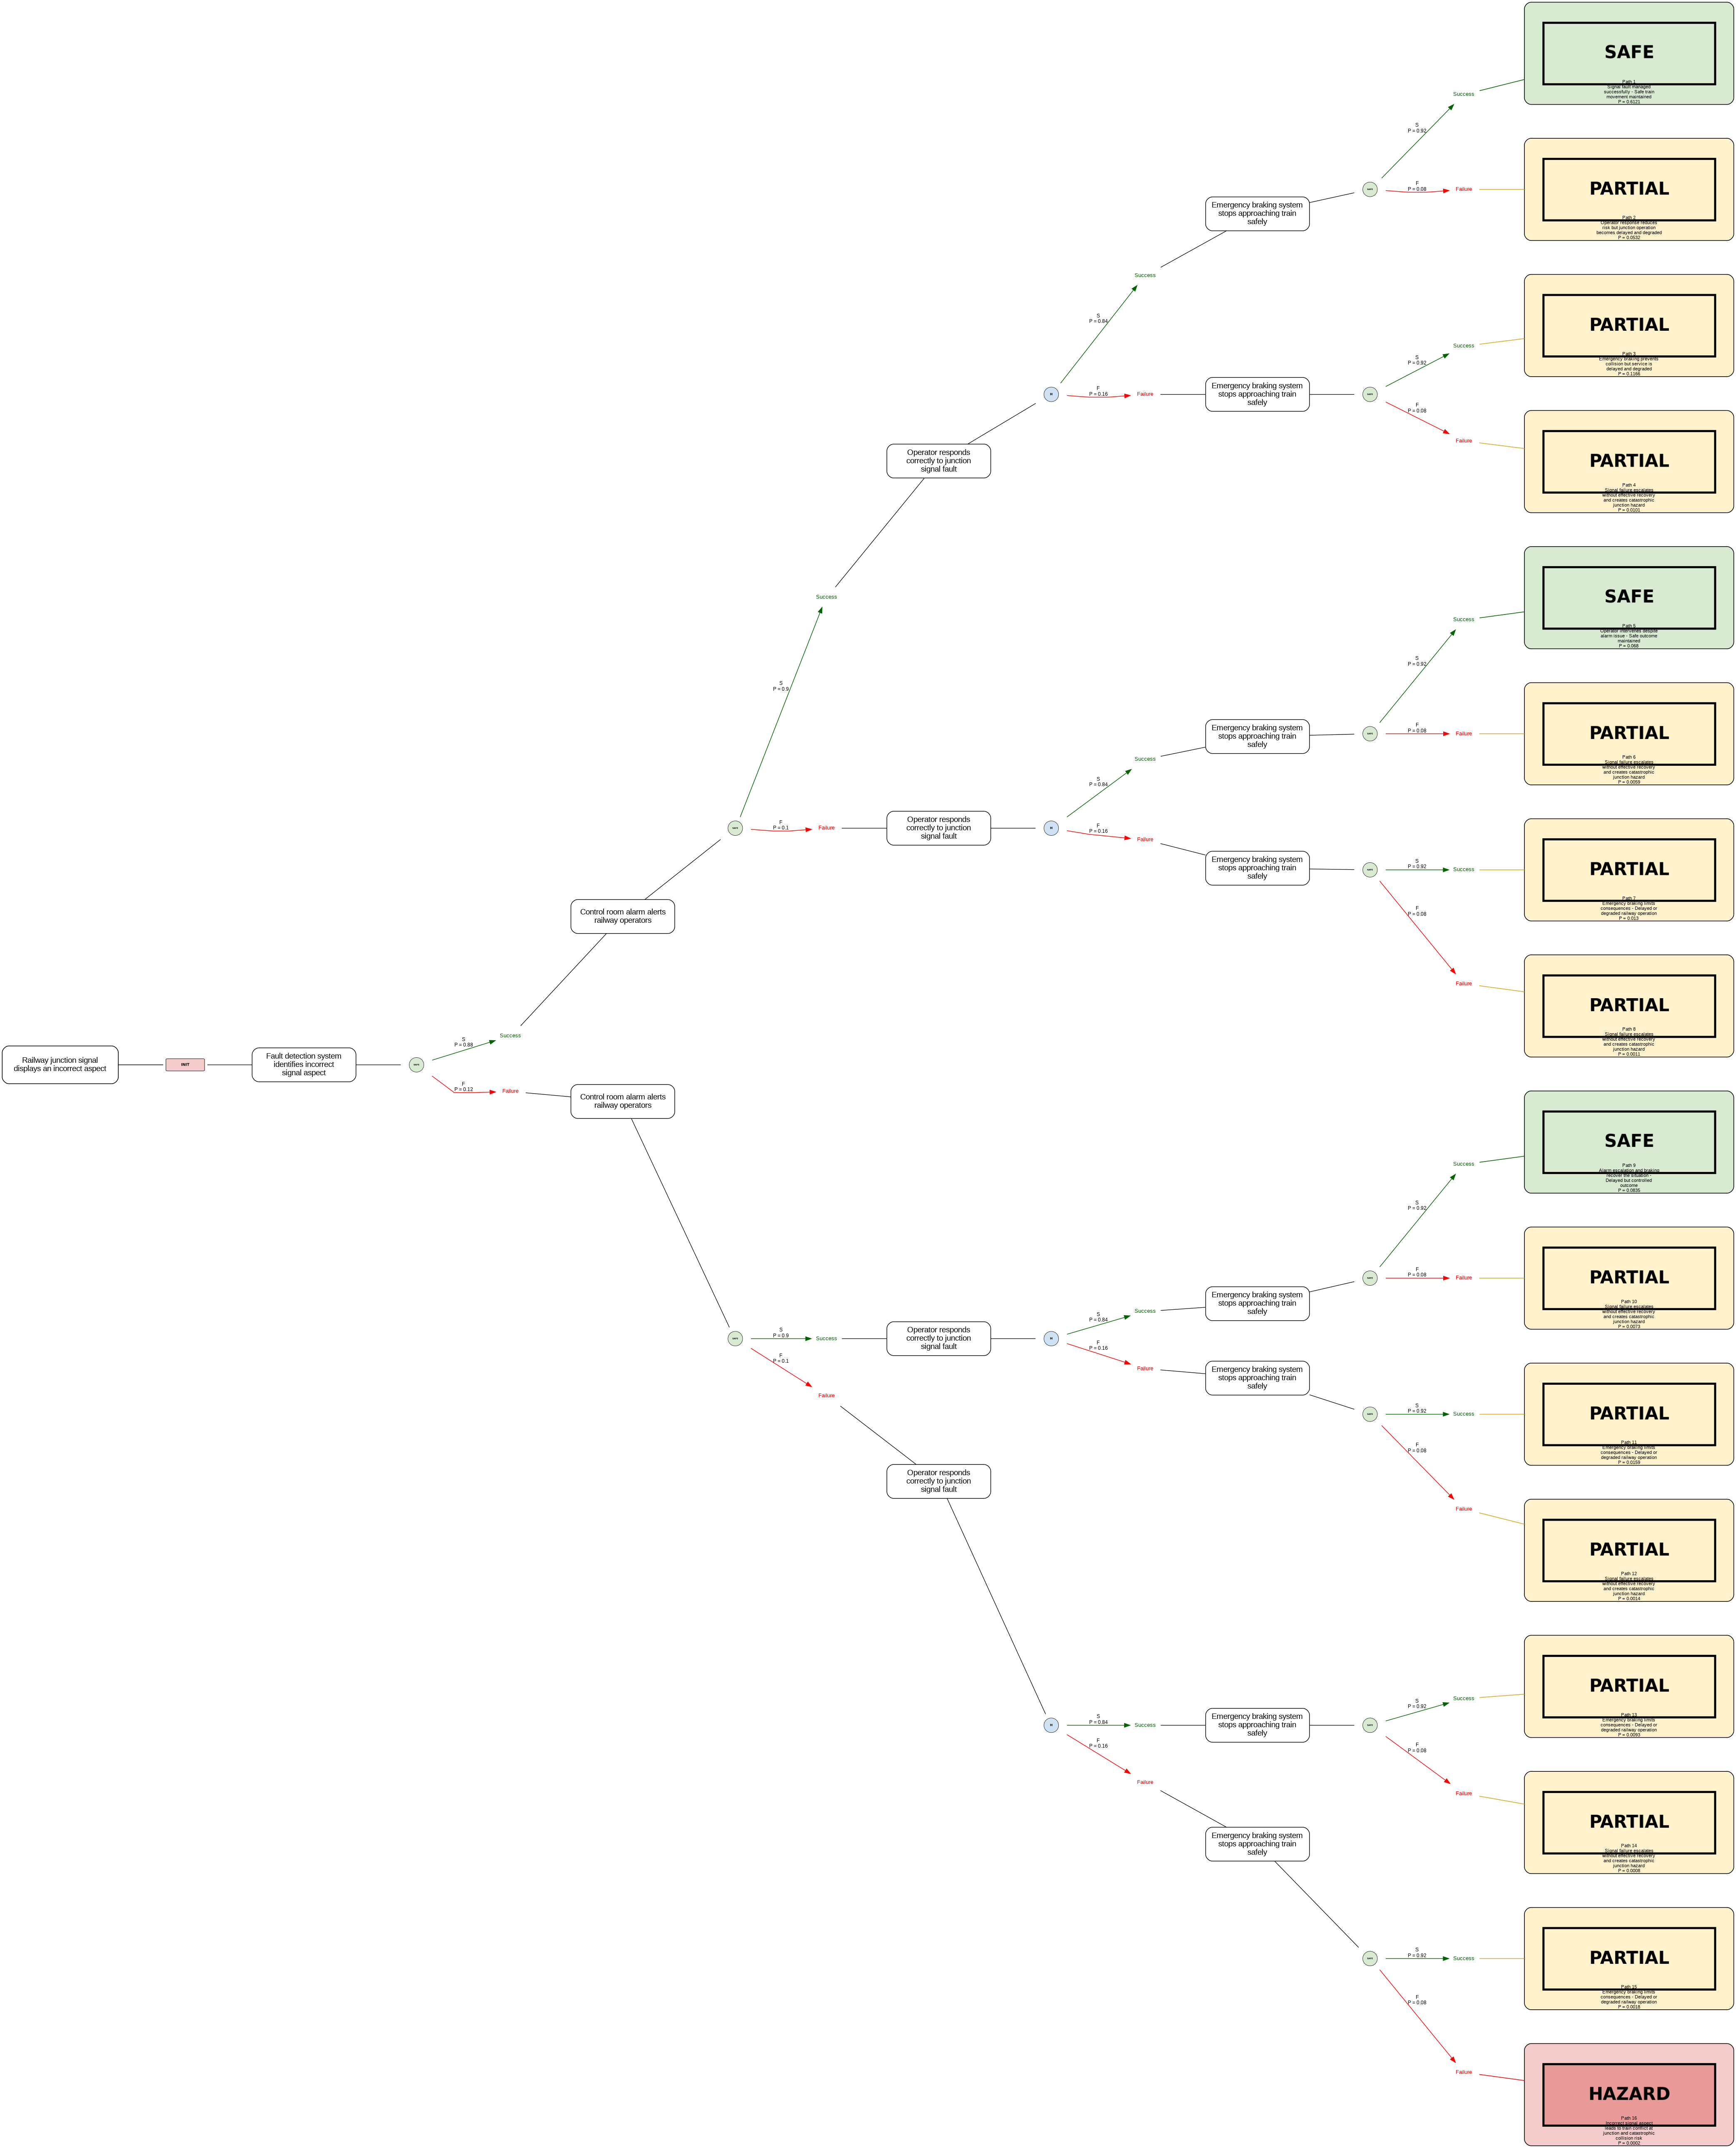

ETA diagram saved as: railway_signal_eta_simple.png


,ID,Barrier,Barrier Type,Success Probability,Failure Probability
0,1,Fault detection system identifies incorrect si...,SAFETY,P = 0.88,P = 0.12
1,2,Control room alarm alerts railway operators,SAFETY,P = 0.9,P = 0.1
2,3,Operator responds correctly to junction signal...,HUMAN,P = 0.84,P = 0.16
3,4,Emergency braking system stops approaching tra...,SAFETY,P = 0.92,P = 0.08


,Path ID,Branch Decisions,Path Probability,Outcome,Outcome Category
0,1,Fault detection system identifies incorrect si...,P = 0.6121,Signal fault managed successfully - Safe train...,SAFE
1,2,Fault detection system identifies incorrect si...,P = 0.0532,Operator response reduces risk but junction op...,PARTIAL FAILURE
2,3,Fault detection system identifies incorrect si...,P = 0.1166,Emergency braking prevents collision but servi...,PARTIAL FAILURE
3,4,Fault detection system identifies incorrect si...,P = 0.0101,Signal failure escalates without effective rec...,PARTIAL FAILURE
4,5,Fault detection system identifies incorrect si...,P = 0.068,Operator intervenes despite alarm issue - Safe...,SAFE
5,6,Fault detection system identifies incorrect si...,P = 0.0059,Signal failure escalates without effective rec...,PARTIAL FAILURE
6,7,Fault detection system identifies incorrect si...,P = 0.013,Emergency braking limits consequences - Delaye...,PARTIAL FAILURE
7,8,Fault detection system identifies incorrect si...,P = 0.0011,Signal failure escalates without effective rec...,PARTIAL FAILURE
8,9,Fault detection system identifies incorrect si...,P = 0.0835,Alarm escalation and braking recover the situa...,SAFE
9,10,Fault detection system identifies incorrect si...,P = 0.0073,Signal failure escalates without effective rec...,PARTIAL FAILURE


,ID,Outcome,Outcome Category,Total Probability
0,1,Signal fault managed successfully - Safe train...,SAFE,P = 0.6121
1,2,Emergency braking prevents collision but servi...,PARTIAL FAILURE,P = 0.1166
2,3,Alarm escalation and braking recover the situa...,SAFE,P = 0.0835
3,4,Operator intervenes despite alarm issue - Safe...,SAFE,P = 0.068
4,5,Operator response reduces risk but junction op...,PARTIAL FAILURE,P = 0.0532
5,6,Emergency braking limits consequences - Delaye...,PARTIAL FAILURE,P = 0.0399
6,7,Signal failure escalates without effective rec...,PARTIAL FAILURE,P = 0.0266
7,8,Incorrect signal aspect leads to train conflic...,CATASTROPHIC FAILURE,P = 0.0002


,ID,Category,Total Probability
0,1,SAFE,P = 0.7635
1,2,PARTIAL FAILURE,P = 0.2363
2,3,CATASTROPHIC FAILURE,P = 0.0002


In [5]:
def railway_signal_outcome_logic(decisions: List[bool]) -> str:
    # First barrier result
    detection_works = decisions[0]

    # Second barrier result
    alarm_works = decisions[1]

    # Third barrier result
    operator_responds = decisions[2]

    # Fourth barrier result
    emergency_braking_works = decisions[3]

    # All barriers work
    if detection_works and alarm_works and operator_responds and emergency_braking_works:
        return "Signal fault managed successfully - Safe train movement maintained"

    # Braking fails but operator responds
    if detection_works and alarm_works and operator_responds and not emergency_braking_works:
        return "Operator response reduces risk but junction operation becomes delayed and degraded"

    # Operator fails but braking works
    if detection_works and alarm_works and not operator_responds and emergency_braking_works:
        return "Emergency braking prevents collision but service is delayed and degraded"

    # Alarm fails but operator and braking recover
    if detection_works and not alarm_works and operator_responds and emergency_braking_works:
        return "Operator intervenes despite alarm issue - Safe outcome maintained"

    # Detection fails but later barriers recover
    if not detection_works and alarm_works and operator_responds and emergency_braking_works:
        return "Alarm escalation and braking recover the situation - Delayed but controlled outcome"

    # All barriers fail
    if (
        not detection_works
        and not alarm_works
        and not operator_responds
        and not emergency_braking_works
    ):
        return "Incorrect signal aspect leads to train conflict at junction and catastrophic collision risk"

    # Emergency braking provides late recovery
    if emergency_braking_works:
        return "Emergency braking limits consequences - Delayed or degraded railway operation"

    # Default severe outcome
    return "Signal failure escalates without effective recovery and creates catastrophic junction hazard"


def build_railway_signal_eta_case() -> EventTree:
    # Define barriers
    barriers = [
        ETABarrier("Fault detection system identifies incorrect signal aspect", 0.88, "SAFETY"),
        ETABarrier("Control room alarm alerts railway operators", 0.90, "SAFETY"),
        ETABarrier("Operator responds correctly to junction signal fault", 0.84, "HUMAN"),
        ETABarrier("Emergency braking system stops approaching train safely", 0.92, "SAFETY"),
    ]

    # Return event tree model
    return EventTree(
        initiating_event="Railway junction signal displays an incorrect aspect",
        barriers=barriers,
        title="Event Tree Analysis of Railway Signal Failure at a Junction",
        outcome_logic=railway_signal_outcome_logic
    )


# Build ETA model
railway_eta = build_railway_signal_eta_case()

# Run dashboard
eta_results = railway_eta.run_dashboard(image_path="railway_signal_eta_simple")

# Display barrier table
display(eta_results["barrier_probability_table"])

# Display path table
display(eta_results["path_outcome_table"])

# Display outcome summary
display(eta_results["final_outcome_summary"])

# Display category comparison
display(eta_results["category_comparison"])